![tower_bridge](tower_bridge.jpeg)

As the climate changes, predicting the weather becomes ever more important for businesses. Since the weather depends on a lot of different factors, you will want to run a lot of experiments to determine what the best approach is to predict the weather. In this project, you will run experiments for different regression models predicting the mean temperature, using a combination of `sklearn` and `MLflow`.

You will be working with data stored in `london_weather.csv`, which contains the following columns:
- **date** - recorded date of measurement - (**int**)
- **cloud_cover** - cloud cover measurement in oktas - (**float**)
- **sunshine** - sunshine measurement in hours (hrs) - (**float**)
- **global_radiation** - irradiance measurement in Watt per square meter (W/m2) - (**float**)
- **max_temp** - maximum temperature recorded in degrees Celsius (°C) - (**float**)
- **mean_temp** - mean temperature in degrees Celsius (°C) - (**float**)
- **min_temp** - minimum temperature recorded in degrees Celsius (°C) - (**float**)
- **precipitation** - precipitation measurement in millimeters (mm) - (**float**)
- **pressure** - pressure measurement in Pascals (Pa) - (**float**)
- **snow_depth** - snow depth measurement in centimeters (cm) - (**float**)

In [101]:
# Run this cell to import the modules you require
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Read in the data
weather = pd.read_csv("london_weather.csv")

# Start coding here
# Use as many cells as you like

In [102]:
weather.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [103]:
weather.isna().sum()

date                   0
cloud_cover           19
sunshine               0
global_radiation      19
max_temp               6
mean_temp             36
min_temp               2
precipitation          6
pressure               4
snow_depth          1441
dtype: int64

In [104]:
weather.shape

(15341, 10)

In [105]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              15341 non-null  int64  
 1   cloud_cover       15322 non-null  float64
 2   sunshine          15341 non-null  float64
 3   global_radiation  15322 non-null  float64
 4   max_temp          15335 non-null  float64
 5   mean_temp         15305 non-null  float64
 6   min_temp          15339 non-null  float64
 7   precipitation     15335 non-null  float64
 8   pressure          15337 non-null  float64
 9   snow_depth        13900 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.2 MB


In [106]:
weather.describe()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
count,1.534100e+04,15322.000000,15341.000000,15322.000000,15335.000000,15305.000000,15339.000000,15335.000000,15337.000000,13900.000000
mean,1.999567e+07,5.268242,4.350238,118.756951,15.388777,11.475511,7.559867,1.668634,101536.605594,0.037986
std,1.212176e+05,2.070072,4.028339,88.898272,6.554754,5.729709,5.326756,3.738540,1049.722604,0.545633
min,1.979010e+07,0.000000,0.000000,8.000000,-6.200000,-7.600000,-11.800000,0.000000,95960.000000,0.000000
25%,1.989070e+07,4.000000,0.500000,41.000000,10.500000,7.000000,3.500000,0.000000,100920.000000,0.000000
50%,2.000010e+07,6.000000,3.500000,95.000000,15.000000,11.400000,7.800000,0.000000,101620.000000,0.000000
75%,2.010070e+07,7.000000,7.200000,186.000000,20.300000,16.000000,11.800000,1.600000,102240.000000,0.000000
max,2.020123e+07,9.000000,16.000000,402.000000,37.900000,29.000000,22.300000,61.800000,104820.000000,22.000000


# Things to Do in order:
1. Data Visualization - To understand how the data is varying, correlations etc.
2. Feature Engineering - Data Cleaning - Normalizing, and Imputation or removal of missing values
3. Model Building & MLflow - MLflow Tracking & MLflow Model & MLflow Datasets
4. Set up the variables

## 1. Data Visualization

In [107]:
print(weather.columns)

Index(['date', 'cloud_cover', 'sunshine', 'global_radiation', 'max_temp',
       'mean_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth'],
      dtype='object')


In [108]:
weather.describe()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
count,1.534100e+04,15322.000000,15341.000000,15322.000000,15335.000000,15305.000000,15339.000000,15335.000000,15337.000000,13900.000000
mean,1.999567e+07,5.268242,4.350238,118.756951,15.388777,11.475511,7.559867,1.668634,101536.605594,0.037986
std,1.212176e+05,2.070072,4.028339,88.898272,6.554754,5.729709,5.326756,3.738540,1049.722604,0.545633
min,1.979010e+07,0.000000,0.000000,8.000000,-6.200000,-7.600000,-11.800000,0.000000,95960.000000,0.000000
25%,1.989070e+07,4.000000,0.500000,41.000000,10.500000,7.000000,3.500000,0.000000,100920.000000,0.000000
50%,2.000010e+07,6.000000,3.500000,95.000000,15.000000,11.400000,7.800000,0.000000,101620.000000,0.000000
75%,2.010070e+07,7.000000,7.200000,186.000000,20.300000,16.000000,11.800000,1.600000,102240.000000,0.000000
max,2.020123e+07,9.000000,16.000000,402.000000,37.900000,29.000000,22.300000,61.800000,104820.000000,22.000000


Text(0.5, 1.0, 'Distribution of cloud cover')

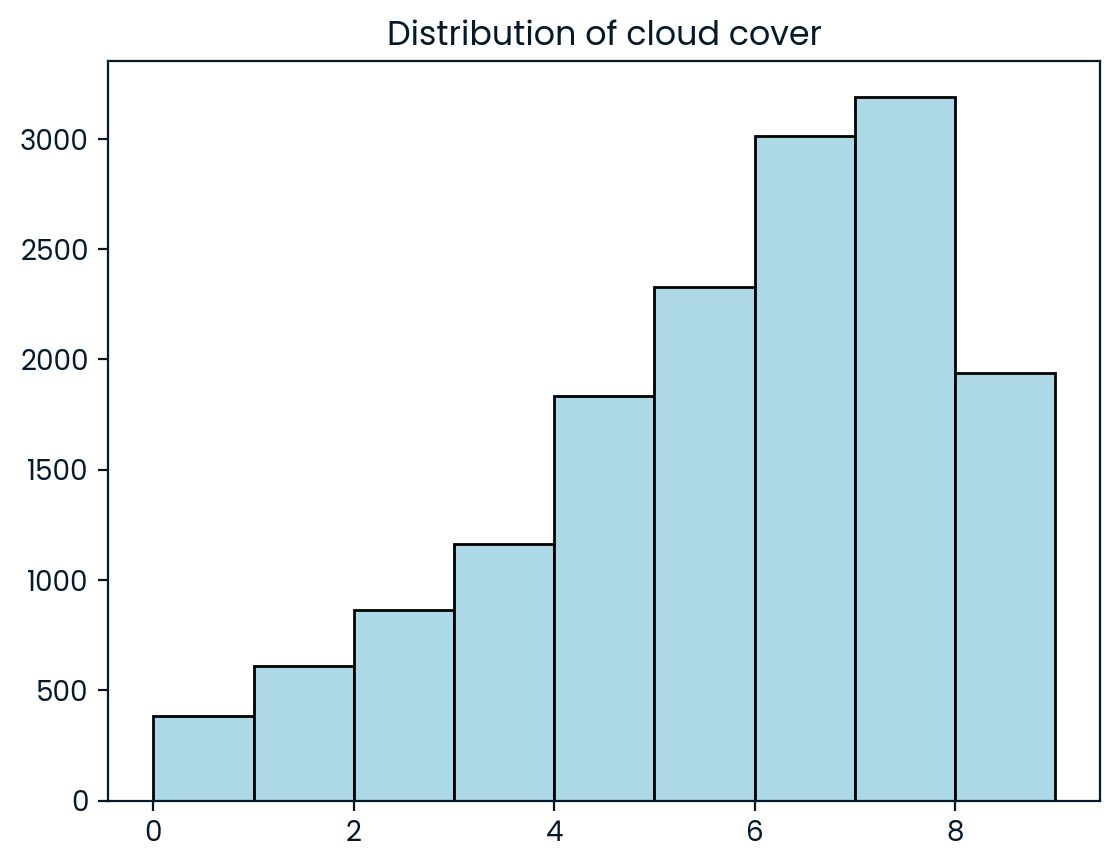

In [109]:
import matplotlib.pyplot as plt
plt.hist(weather['cloud_cover'],bins=9,color='lightblue',edgecolor='black')
plt.title('Distribution of cloud cover')

Text(0.5, 1.0, 'Distribution of sunshine')

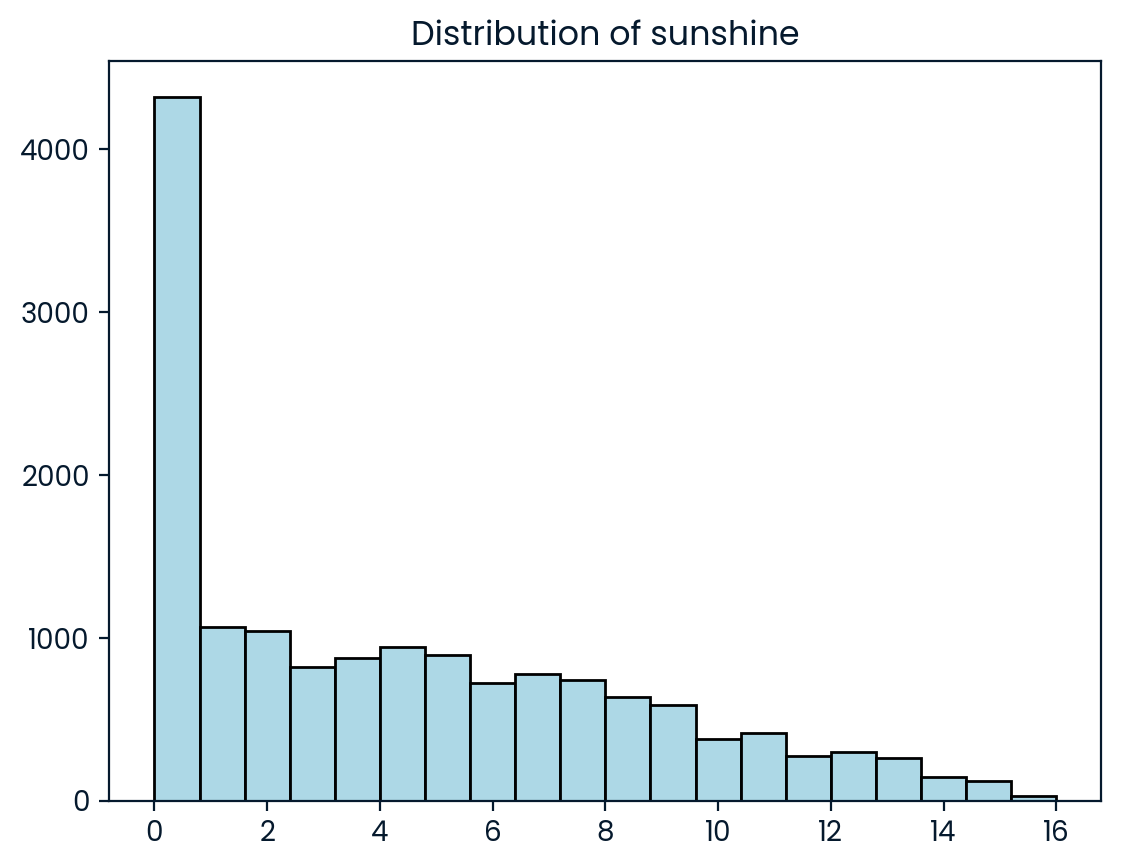

In [110]:
plt.hist(weather['sunshine'],bins=20,color='lightblue',edgecolor='black')
plt.title('Distribution of sunshine')

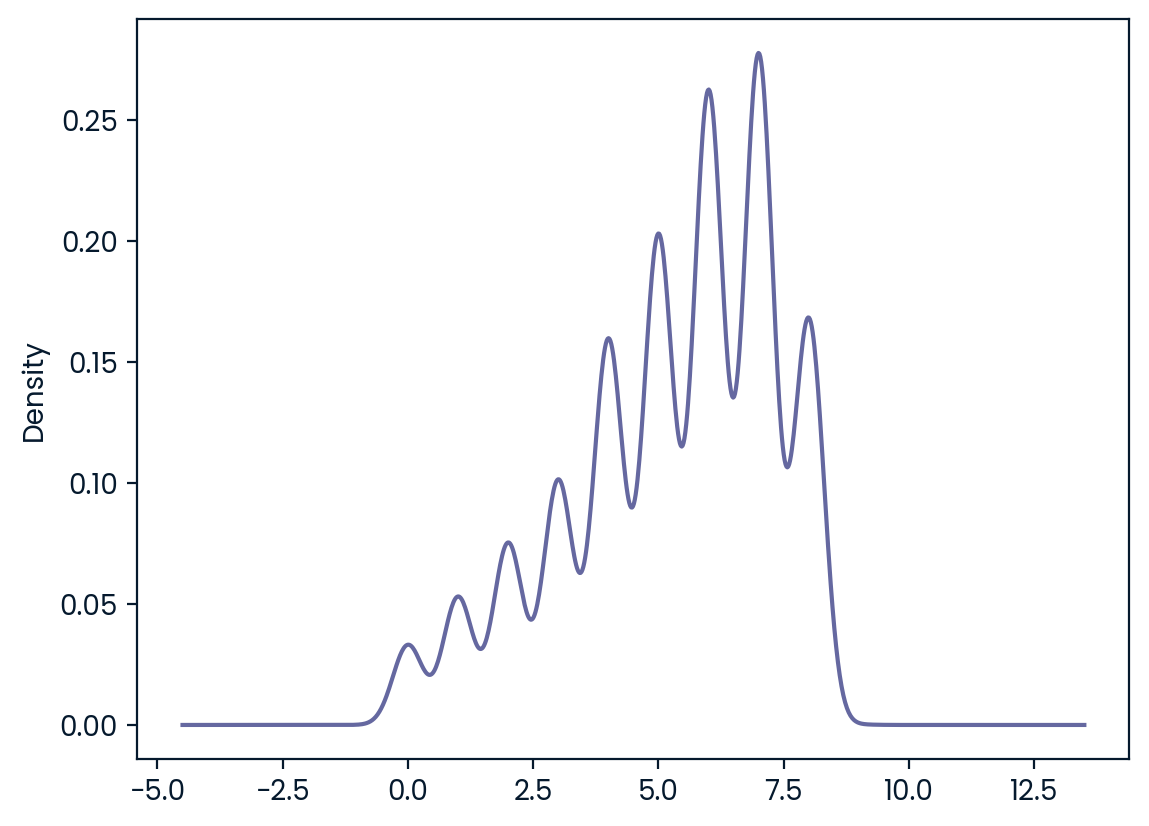

In [111]:
weather['cloud_cover'].plot.density()
plt.show()

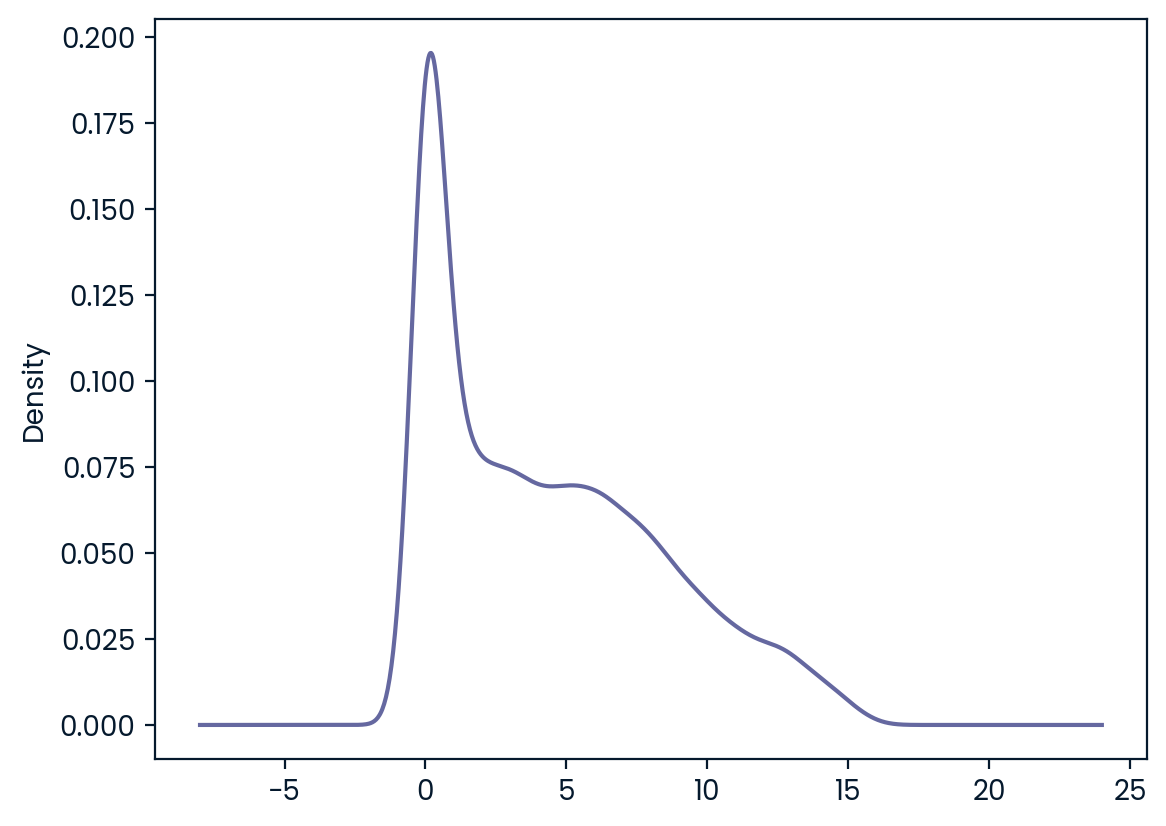

In [112]:
weather['sunshine'].plot.density()
plt.show()

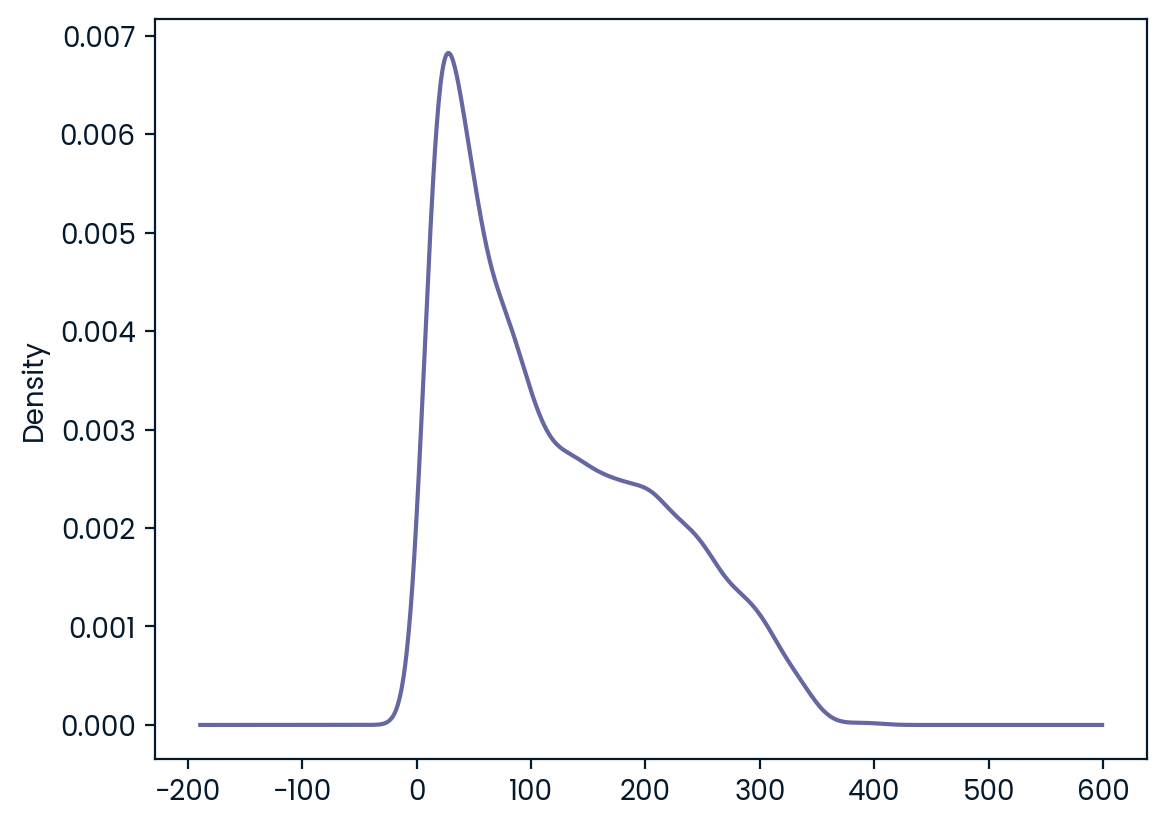

In [113]:
weather['global_radiation'].plot.density()
plt.show()

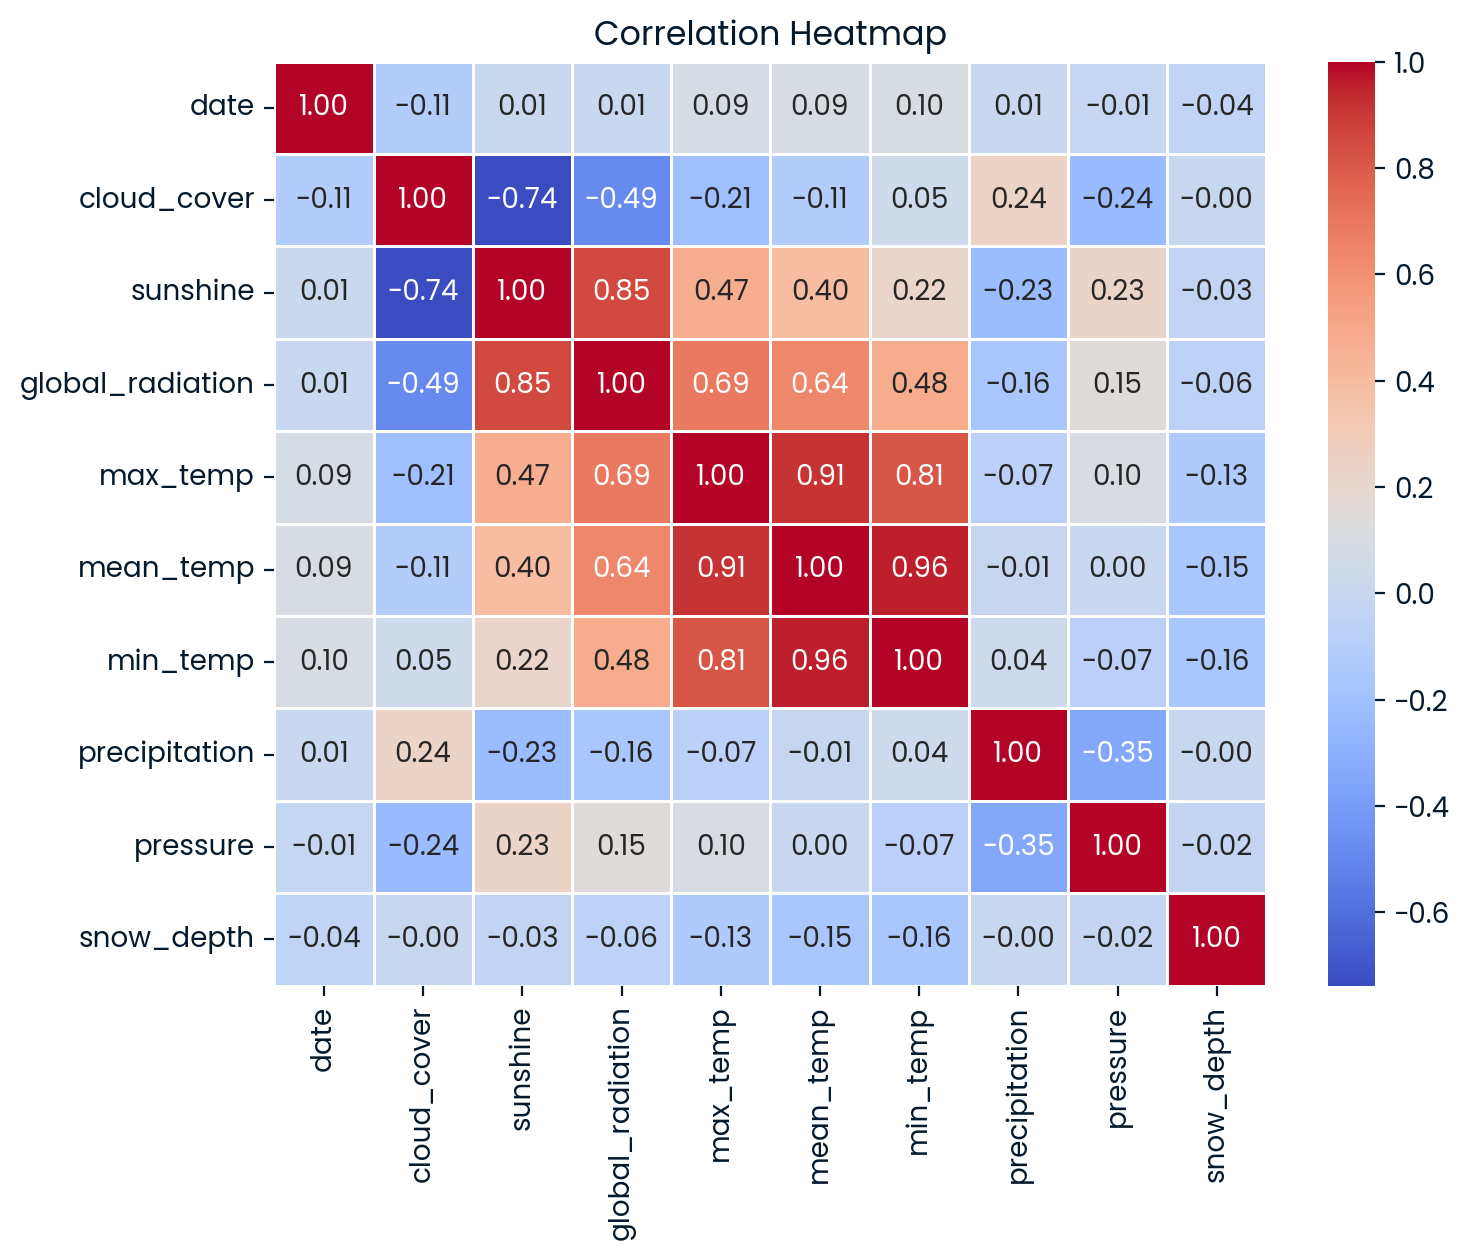

In [114]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(weather.corr(),annot=True,cmap='coolwarm',fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Observations:
1. Need to normalize the date column by subtracting the first date from all others.
2. Sunshine, global_radiation, max_temp and min_temp have the highest correlation with the **target variable**
3. (cloud_cover, sunshine) - (-)0.74, (cloud_cover,global_radiation) - (-)0.49, (sunshine, global_radiation) - 0.85, (global_radiation,max_temp) - 0.69, (global_radiation, min_temp) - 0.48 are also **correlated**.
4. **date**, **cloud_cover** and **precipitation** columns are very **weakly correlated** to the **mean_temp**. cloud_cover is correlated to other variables that are correlated to the output, but is not itself directly correlated to the output.
5. **Pressure** is **not correlated** to the mean_temp at all.
6. **date** should not be correlated much as well as it does not give any indication as to the temperature of the day.
7. It is valid to drop **date**, **precipitation** , and **snow_depth**. Even though **cloud_cover** is weakly correlated, it being correlated to other variables and not with output variable is interesting.
8. Imputing the **mean_temp** is not a right idea as it could include bias to the prediction

In [115]:
mlflow.set_experiment('Mean Temp Prediction')

<Experiment: artifact_location='file:///work/files/workspace/mlruns/191563073760811737', creation_time=1770620588543, experiment_id='191563073760811737', last_update_time=1770620588543, lifecycle_stage='active', name='Mean Temp Prediction', tags={}>

In [116]:
weather.drop(['date','pressure','precipitation','snow_depth'],axis=1,inplace=True)

In [117]:
weather.describe()

,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp
count,15322.000000,15341.000000,15322.000000,15335.000000,15305.000000,15339.000000
mean,5.268242,4.350238,118.756951,15.388777,11.475511,7.559867
std,2.070072,4.028339,88.898272,6.554754,5.729709,5.326756
min,0.000000,0.000000,8.000000,-6.200000,-7.600000,-11.800000
25%,4.000000,0.500000,41.000000,10.500000,7.000000,3.500000
50%,6.000000,3.500000,95.000000,15.000000,11.400000,7.800000
75%,7.000000,7.200000,186.000000,20.300000,16.000000,11.800000
max,9.000000,16.000000,402.000000,37.900000,29.000000,22.300000


## 2. Feature Engineering

In [118]:
weather.dropna(subset=['mean_temp'],inplace=True) # 36 rows dropped.

In [119]:
weather.shape

(15305, 6)

In [120]:
weather.isna().sum()

cloud_cover         19
sunshine             0
global_radiation    19
max_temp             0
mean_temp            0
min_temp             0
dtype: int64

In [121]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

cc_imp = IterativeImputer()
weather['cloud_cover'] = cc_imp.fit_transform(weather['cloud_cover'].values.reshape(-1,1))

gr_imp = IterativeImputer()
weather['global_radiation'] = gr_imp.fit_transform(weather['global_radiation'].values.reshape(-1,1))

In [122]:
weather.isna().sum()

cloud_cover         0
sunshine            0
global_radiation    0
max_temp            0
mean_temp           0
min_temp            0
dtype: int64

In [123]:
weather.describe()

,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp
count,15305.000000,15305.000000,15305.000000,15305.000000,15305.000000,15305.000000
mean,5.267107,4.352382,118.758864,15.386893,11.475511,7.556576
std,2.068773,4.028954,88.834937,6.555723,5.729709,5.326749
min,0.000000,0.000000,8.000000,-6.200000,-7.600000,-11.800000
25%,4.000000,0.500000,41.000000,10.500000,7.000000,3.500000
50%,6.000000,3.500000,95.000000,15.000000,11.400000,7.800000
75%,7.000000,7.200000,186.000000,20.300000,16.000000,11.800000
max,9.000000,16.000000,402.000000,37.900000,29.000000,22.300000


In [124]:
cols = ['cloud_cover','sunshine','global_radiation','max_temp','min_temp']
X = weather.loc[:,cols].values
y = weather['mean_temp']

## Nothing else needed
Checklist
1. Not categorical variables
2. No Missing values left
3. No variable transformation - all the columns are in a nice range of values
4. no discretization needed
5. outlier engineering - data seems to be in order
6. no date and time engineering needed

## 3. Model Building and MLflow

In [125]:
with mlflow.start_run() as last_run:
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_squared_error
    from sklearn.tree import DecisionTreeRegressor
    mlflow.sklearn.autolog()
    
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=45)
    reg = DecisionTreeRegressor()
    reg.fit(X_train,y_train)
    # mlflow.sklearn.log_model()
    y_pred_train = reg.predict(X_train)
    y_pred_test = reg.predict(X_test)
    rmse_train = mean_squared_error(y_pred_train,y_train,squared=False)
    rmse_test = mean_squared_error(y_pred_test,y_test,squared=False)
    mlflow.log_metric("rmse_train",rmse_train)
    mlflow.log_metric("rmse_test",rmse_test)
    # mlflow.log_param("test_size",0.3)
    # mlflow.log_param("random_state",45)
    
    print("Training data rmse :",rmse_train)
    print("Testing data rmse :",rmse_test)


2026/02/09 07:53:59 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/02/09 07:54:01 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpycb2_juu/model/model.pkl, flavor: sklearn), fall back to return ['scikit-learn==1.3.2', 'cloudpickle==2.1.0']. Set logging level to DEBUG to see the full traceback.


Training data rmse : 0.017880297292562533
Testing data rmse : 1.21781451410572


In [126]:
experiment_results = mlflow.search_runs()

In [ ]:
import zipfile
import os


def getallfiles(directory):
    if os.path.isdir(directory):
        lst = []
        for file in os.listdir(directory):
            file = os.path.join(directory,file)
            if os.path.isdir(file):
                lst.extend(getallfiles(file))
            else:
                lst.append(file)
        return lst
    else:
        return [directory]
    
files_to_zip = getallfiles('.') # List of files to add

with zipfile.ZipFile("Temperature Prediction.", "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)
        else:
            print(f"Warning: {file} not found and skipped.")
# The file "my_archive.zip" is created in your notebook's directory
